# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from helpers import *

# Raincloud plot of beta distributions per monkey and area

plt.rcParams.update({'font.size': 8})



/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-gok3_6ue because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new = behav_new.dropna()

In [3]:
#count nans
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.150551,0.204889,0.355440,0.283056,0.069825,-0.213231,-0.117508,-0.109746,0.007762
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.204889,-0.059881,-0.264770,0.069825,0.069825,0.000000,-0.109746,-0.055993,0.053753
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.059881,-0.200961,-0.141080,0.069825,0.479459,0.409634,-0.055993,0.064920,0.120912
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.200961,-0.070287,0.130675,0.479459,0.283056,-0.196402,0.064920,-0.083296,-0.148216
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.070287,-0.073770,-0.003484,0.283056,0.167107,-0.115949,-0.083296,0.035119,0.118415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,0.796248,0.689507,-0.106742,0.723918,0.503993,-0.219925,0.706391,-0.005228,-0.711619
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,0.689507,0.057016,-0.632490,0.503993,0.654679,0.150686,-0.005228,0.390832,0.396059
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.057016,0.362536,0.305519,0.654679,0.759587,0.104908,0.390832,0.261081,-0.129750
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.362536,0.786138,0.423602,0.759587,0.832624,0.073037,0.261081,0.440961,0.179879


In [4]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (1.5, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.769454,0.812984,1.582438,0.283056,0.069825,-0.213231,-0.907589,-0.853688,0.053901
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.811088,-0.362970,-1.174057,0.069825,0.069825,0.000000,-0.848967,-0.447462,0.401505
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.366271,-0.989564,-0.623293,0.069825,0.479459,0.409634,-0.443023,0.466314,0.909337
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.993615,-0.409184,0.584431,0.479459,0.283056,-0.196402,0.470115,-0.653801,-1.123917
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.412541,-0.424657,-0.012115,0.283056,0.167107,-0.115949,-0.649219,0.241101,0.890320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,1.174154,1.031969,-0.142184,0.723918,0.503993,-0.219925,1.895587,-0.036211,-1.931798
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,1.031827,0.190688,-0.841139,0.503993,0.654679,0.150686,-0.031474,1.038479,1.069952
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.188484,0.597062,0.408579,0.654679,0.759587,0.104908,1.041053,0.686407,-0.354646
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.595854,1.160500,0.564645,0.759587,0.832624,0.073037,0.689690,1.174502,0.484812


---
# Test

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

alpha = 0.05  # significance level

# -----------------------------
# Pick time window & session
# -----------------------------
time_interval = (1.5, 3.5)  # time window for V_t and V_t+1
behav_new['V_t']    = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']

res = []  # if not yet defined

for (monkey, session, subregion), behav_new_temp in behav_new.groupby(['monkey', 'session', 'subregion']):

    # Extract datapoints (FILTERED)
    V_t = behav_new_temp['V_t'].values
    V_t1 = behav_new_temp['V_t_p1'].values
    fb_vector = behav_new_temp['feedback'].values

    # create a dataframe, column A is V_t1, B is V_t, C is fb_vector
    data_temp = pd.DataFrame({
        'A': V_t1,
        'B': V_t,
        'C': fb_vector
    })

    results_mixed = fit_mixed_glm(data_temp)
    test_results = stat_tests_mixed_glm(results_mixed)
    hypothesis = add_hypothesis(test_results)

    # -----------------------------
    # Package per-session results (trimmed)
    # -----------------------------
    session_result = {
        'monkey': monkey,
        'session': session,
        'subregion': subregion,

        # mean(Vt+1) comparison
        #'mean_vt1_pos': mean_vt1_pos,
        #'mean_vt1_neg': mean_vt1_neg,
        #'p_neg_mean_lt_pos': p_neg_mean_lt_pos,

        # regression summaries
        #'slope_all': slope_all,
        #'intercept_all': intercept_all,
        #'r2_all': np.nan if np.isnan(r_all) else r_all**2,
        #'p_model_all': p_all,          # slope 2-sided p in simple LR

        'slope_pos': test_results['slope_c1'],
        'intercept_pos': test_results['intercept_c1'],
        #'r2_pos': np.nan if np.isnan(r_pos) else r_pos**2,
        'slope_pos_nonzero': test_results['b1_c1_significant'],          # slope 2-sided p in simple LR
        'slope_pos_withinbounds': test_results['b1_c1_within_bounds'],          # slope 2-sided p in simple LR

        'slope_neg': test_results['slope_c0'],
        'intercept_neg': test_results['intercept_c0'],
        #'r2_neg': np.nan if np.isnan(r_neg) else r_neg**2,
        'slope_neg_nonzero': test_results['b1_c0_significant'],          # slope 2-sided p in simple LR
        'slope_neg_withinbounds': test_results['b1_c0_within_bounds'],          # slope 2-sided p in simple LR

        # intercept higher
        'intercept_pos_higher': test_results['intercept_c1_higher'],

        # Add hypothesis
        'hypothesis': hypothesis,

        # one-tailed tests for slope constraints
        #'p_pos_gt0': p_pos_gt0,
        #'p_pos_lt1': p_pos_lt1,
        #'p_neg_gt0': p_neg_gt0,
        #'p_neg_lt1': p_neg_lt1,
    }

    res.append(session_result)

res_df = pd.DataFrame(res)
res_df


,monkey,session,subregion,slope_pos,intercept_pos,slope_pos_nonzero,slope_pos_withinbounds,slope_neg,intercept_neg,slope_neg_nonzero,slope_neg_withinbounds,intercept_pos_higher,hypothesis
0,ka,010720,MCC,0.381777,0.409542,True,True,0.468393,-0.435312,True,True,True,Delta rule (strict)
1,ka,010720,vLPFC,0.221830,0.162352,True,True,0.132338,-0.195063,False,False,True,Delta rule (loose)
2,ka,010822,MCC,0.125676,0.182373,False,False,0.020985,-0.266862,False,False,True,Feedback
3,ka,010822,dLPFC,-0.036710,0.108383,False,False,-0.057459,-0.156559,False,False,True,Feedback
4,ka,010922,MCC,-0.281018,-0.000861,True,False,0.104301,0.084863,False,False,False,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,po,300322,vLPFC,0.142118,0.146257,True,True,0.176821,-0.137341,True,True,True,Delta rule (strict)
210,po,300421,MCC,0.322608,0.312150,True,True,0.273197,-0.350941,True,True,True,Delta rule (strict)
211,po,300421,dLPFC,0.102604,0.123857,False,False,0.111325,-0.135177,False,False,True,Feedback
212,po,310822,MCC,0.616231,0.083035,True,True,0.688054,-0.071550,True,True,True,Delta rule (strict)


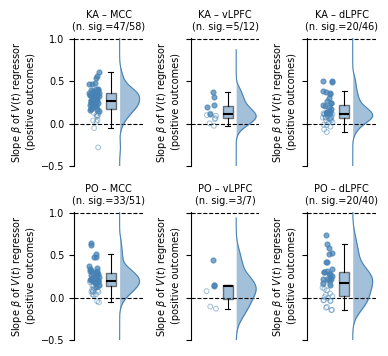

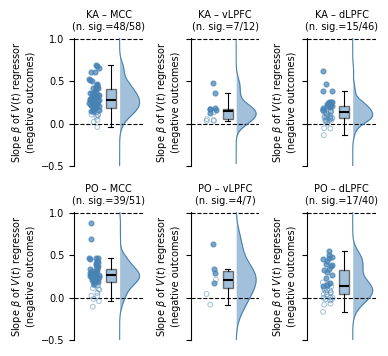

In [6]:
plot_betas(res_df)

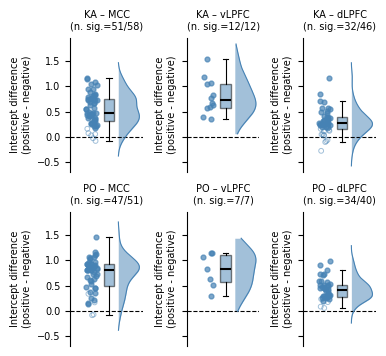

In [7]:
plot_intercept_differences(res_df)

In [8]:
res_df

,monkey,session,subregion,slope_pos,intercept_pos,slope_pos_nonzero,slope_pos_withinbounds,slope_neg,intercept_neg,slope_neg_nonzero,slope_neg_withinbounds,intercept_pos_higher,hypothesis
0,ka,010720,MCC,0.381777,0.409542,True,True,0.468393,-0.435312,True,True,True,Delta rule (strict)
1,ka,010720,vLPFC,0.221830,0.162352,True,True,0.132338,-0.195063,False,False,True,Delta rule (loose)
2,ka,010822,MCC,0.125676,0.182373,False,False,0.020985,-0.266862,False,False,True,Feedback
3,ka,010822,dLPFC,-0.036710,0.108383,False,False,-0.057459,-0.156559,False,False,True,Feedback
4,ka,010922,MCC,-0.281018,-0.000861,True,False,0.104301,0.084863,False,False,False,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,po,300322,vLPFC,0.142118,0.146257,True,True,0.176821,-0.137341,True,True,True,Delta rule (strict)
210,po,300421,MCC,0.322608,0.312150,True,True,0.273197,-0.350941,True,True,True,Delta rule (strict)
211,po,300421,dLPFC,0.102604,0.123857,False,False,0.111325,-0.135177,False,False,True,Feedback
212,po,310822,MCC,0.616231,0.083035,True,True,0.688054,-0.071550,True,True,True,Delta rule (strict)


In [9]:
# save this df in results
to_save = res_df[['monkey', 'session', 'subregion', 'hypothesis']]
floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'neural_value', 'results', 'hypotheses_summary.pkl')
to_save.to_pickle(floc)

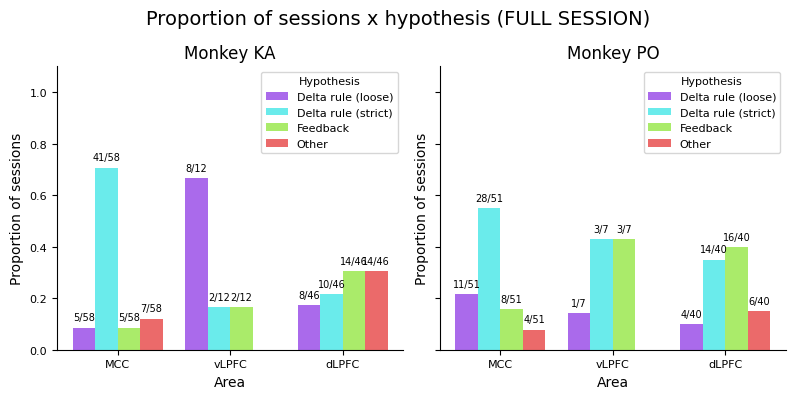

In [19]:
# Plot proportion of sessions per area supporting each hypothesis
# One plot per monkey, with bars for each hypothesis at each area tick

import matplotlib.colors as mcolors
plt.rcParams.update({'font.size': 8})

# Get unique monkeys, areas, and hypotheses
monkeys = res_df['monkey'].unique()
areas = res_df['subregion'].unique()
hypotheses = sorted(res_df['hypothesis'].dropna().unique())

# Assign arbitrary but distinct colors to each hypothesis
rng = np.random.default_rng(42)
hues = np.linspace(0, 1, len(hypotheses), endpoint=False)
rng.shuffle(hues)
hypothesis_colors = {
    hyp: mcolors.to_hex(mcolors.hsv_to_rgb((h, 0.7, 0.9)))
    for hyp, h in zip(hypotheses, hues)
}

# Create figure with one subplot per monkey
fig, axs = plt.subplots(1, len(monkeys), figsize=(4 * len(monkeys), 4), sharey=True)
if len(monkeys) == 1:
    axs = [axs]

for i, monkey in enumerate(monkeys):
    ax = axs[i]
    
    # Filter data for this monkey
    monkey_data = res_df[res_df['monkey'] == monkey]
    
    # Calculate proportions and counts for each area and hypothesis
    proportions = {}
    counts = {}
    totals = {}
    for area in areas:
        area_data = monkey_data[monkey_data['subregion'] == area]
        total_sessions = len(area_data)
        totals[area] = total_sessions
        
        proportions[area] = {}
        counts[area] = {}
        for hyp in hypotheses:
            hyp_count = len(area_data[area_data['hypothesis'] == hyp])
            counts[area][hyp] = hyp_count
            proportions[area][hyp] = hyp_count / total_sessions if total_sessions > 0 else 0
    
    # Set up bar positions
    x_positions = np.arange(len(areas))
    bar_width = 0.8 / len(hypotheses)
    
    # Plot bars for each hypothesis
    for j, hyp in enumerate(hypotheses):
        positions = x_positions + (j - len(hypotheses)/2 + 0.5) * bar_width
        values = [proportions[area].get(hyp, 0) for area in areas]
        
        color = hypothesis_colors[hyp]
        
        bars = ax.bar(positions, values, bar_width, label=hyp, color=color, alpha=0.8)
        
        # Add text annotations with count/total format
        for k, (pos, val, area) in enumerate(zip(positions, values, areas)):
            count = counts[area].get(hyp, 0)
            total = totals[area]
            if count > 0:  # Only show label if there are sessions
                ax.text(pos, val + 0.02, f'{count}/{total}', 
                       ha='center', va='bottom', fontsize=7, rotation=0)
    
    # Formatting
    ax.set_xlabel('Area', fontsize=10)
    ax.set_ylabel('Proportion of sessions', fontsize=10)
    ax.set_title(f'Monkey {monkey.upper()}', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(areas)
    ax.set_ylim(0, 1.1)  # Increased to accommodate text labels
    ax.legend(title='Hypothesis', fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('Proportion of sessions x hypothesis (FULL SESSION)', fontsize=14)

plt.tight_layout()
plt.show()

In [11]:
# Print delta statistics in the requested format
total_sessions = len(res_df)
delta_sessions = len(res_df[res_df['hypothesis'] == 'delta'])
delta_pct = (delta_sessions / total_sessions) * 100

# Build statistics string in exact format requested
stats_parts = []
for monkey in ['ka', 'po']:
    monkey_data = res_df[res_df['monkey'] == monkey]
    for area in res_df['subregion'].unique():
        area_data = monkey_data[monkey_data['subregion'] == area]
        total_area = len(area_data)
        if total_area > 0:
            delta_count = len(area_data[area_data['hypothesis'] == 'delta'])
            pct = (delta_count / total_area) * 100
            stats_parts.append(f"{monkey.upper()} – {area}: {delta_count}/{total_area}, {pct:.1f}%")

print(f"Under p < 0.05, {delta_pct:.1f}% of all sessions ({delta_sessions} of all {total_sessions}) passed all three criteria ({'; '.join(stats_parts)})")

Under p < 0.05, 0.0% of all sessions (0 of all 214) passed all three criteria (KA – MCC: 0/58, 0.0%; KA – vLPFC: 0/12, 0.0%; KA – dLPFC: 0/46, 0.0%; PO – MCC: 0/51, 0.0%; PO – vLPFC: 0/7, 0.0%; PO – dLPFC: 0/40, 0.0%)


---
# Plot slopes on the cortical surface
to see is there is a spatial pattern in the significant slopes (e.g., more significant slopes in certain areas of the cortex).

In [12]:
def add_cortical_position(sessions_df):
    from popy.plotting.plot_cortical_grid import _get_grid_location
    """ adds xy coordinates of cortical position for each recording. """
    df = sessions_df.copy()

    # add empty coordinate columns
    df['x'] = np.nan
    df['y'] = np.nan
        
    # load positions
    for idx, row in df.iterrows():
        monkey_temp = row['monkey']
        session_temp = row['session']
        area_temp = row['area']

        if area_temp in ['dLPFC', 'vLPFC']: area_temp = 'LPFC'
        
        grid_loc = _get_grid_location(monkey_temp, session_temp, area_temp)
        
        # add coordinates to the dataframe
        df.loc[idx, 'x'] = grid_loc[0]
        df.loc[idx, 'y'] = grid_loc[1]
    
    return df

In [13]:
# Extract session information: monkey, session, area (subregion), mean slope, hypothesis
sessions_df = res_df[['monkey', 'session', 'subregion']].copy()
sessions_df['mean_slope'] = (res_df['slope_pos'] + res_df['slope_neg']) / 2
sessions_df['hypothesis'] = res_df['hypothesis']
sessions_df = sessions_df.rename(columns={'subregion': 'area'})
sessions_df = sessions_df[(sessions_df['hypothesis'] == 3) & (sessions_df['area'].isin(['MCC']))] # filter to the three subregions of interest
# Apply the function
sessions_df = add_cortical_position(sessions_df)
sessions_df


,monkey,session,area,mean_slope,hypothesis,x,y


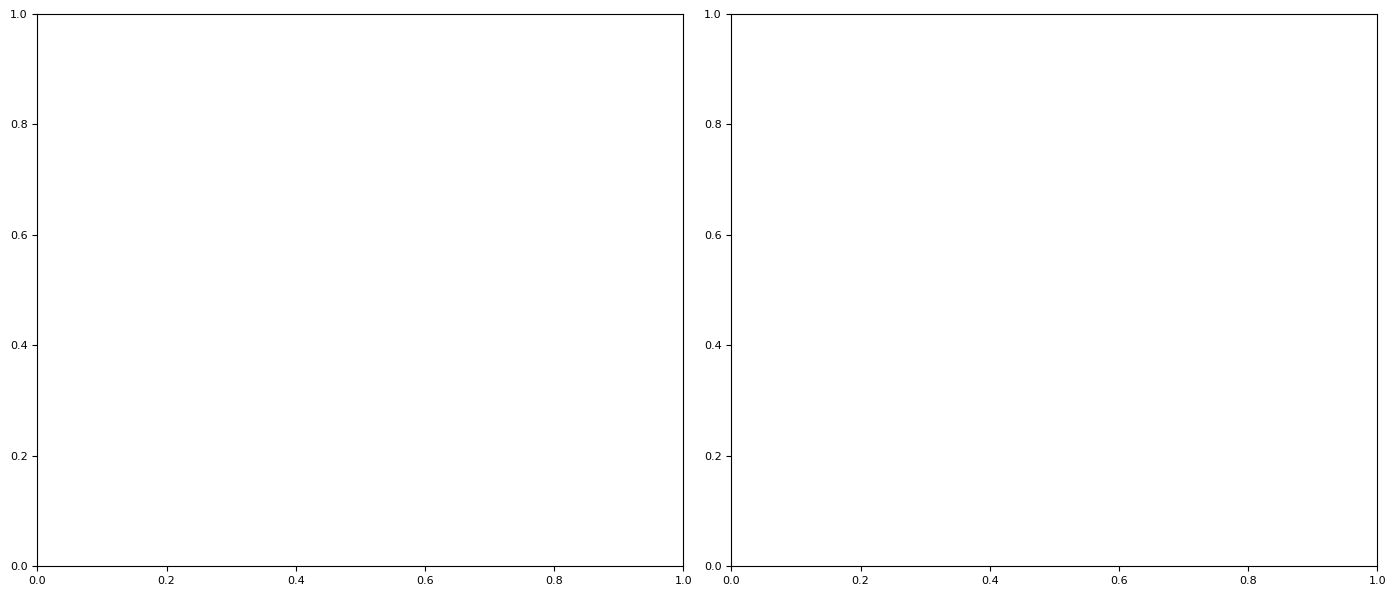

In [14]:
# Plot best alpha per monkey on x-y coordinate system
import matplotlib.pyplot as plt
import numpy as np

# Get unique monkeys
monkeys = sessions_df['monkey'].unique()

# Create a figure with 2 subplots (one per monkey)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, monkey in enumerate(monkeys):
    # Filter data for this monkey
    monkey_data = sessions_df[sessions_df['monkey'] == monkey].copy()
        
    # Create scatter plot
    scatter = axes[i].scatter(
        monkey_data['x'], 
        monkey_data['y'], 
        c=monkey_data['mean_slope'],
        s=100,
        cmap='viridis',
        alpha=0.7,
        edgecolors='black',
        linewidths=0.5
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[i])
    cbar.set_label('Mean Slope', rotation=270, labelpad=20)
    
    # Set labels and title
    axes[i].set_xlabel('X coordinate')
    axes[i].set_ylabel('Y coordinate')
    axes[i].set_title(f'Monkey: {monkey.upper()}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_aspect('equal', adjustable='box')

    # xlim and y lim : -10 to 10
    axes[i].set_xlim(-10, 10)
    axes[i].set_ylim(-10, 10)

plt.tight_layout()
plt.show()

print an example session

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='$V_t$', ylabel='$V_{t+1}$'>)

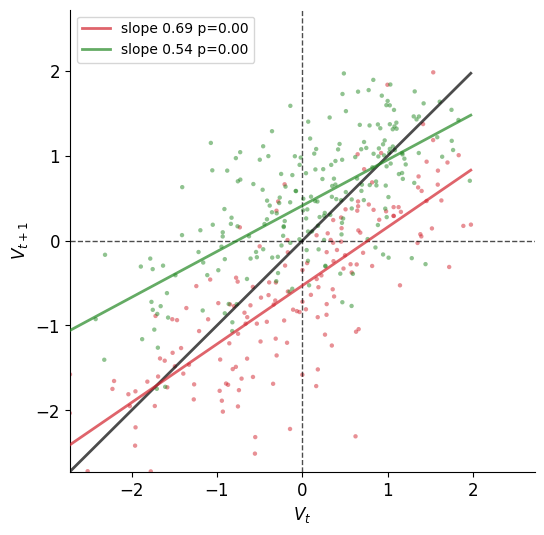

In [15]:
monkey, session, subregion = 'ka', '210322', 'MCC'
behav_new_temp = behav_new[(behav_new.monkey==monkey) & (behav_new.session==session) & (behav_new.subregion==subregion)]
'''
monkeys = ['ka', 'po']
area = 'MCC'
sessions = res_df.loc[(res_df.monkey.isin(monkeys)) & (res_df.subregion==area) & (res_df.hypothesis==4), 'session'].unique()
    
behav_new_temp = behav_new[(behav_new.monkey.isin(monkeys)) & (behav_new.subregion==area) & (behav_new.session.isin(sessions))]
print(f"Plotting {len(behav_new_temp)} trials from {len(sessions)} sessions in {area} for monkeys {monkeys} (H2 Delta rule)")

# Example usage:
V_t = behav_new_temp['V_t'].values
V_t1 = behav_new_temp['V_t_p1'].values
fb_vector = behav_new_temp['feedback'].values
'''
# random shuffling all

green_red_plot(behav_new_temp, paper_format=False)

In [16]:
import numpy as np
import pandas as pd
from scipy import stats

# === Extra helpers ===
def two_tailed_from_t(t, df):
    if not np.isfinite(t) or df is None or df <= 0:
        return np.nan
    return 2 * (1 - stats.t.cdf(abs(t), df))

def p_eq1_two(slope, se, df):
    if not (np.isfinite(slope) and np.isfinite(se) and se > 0 and df > 0):
        return np.nan
    t = (slope - 1.0) / se
    return two_tailed_from_t(t, df)

def p_eq0_two(slope, se, df):
    if not (np.isfinite(slope) and np.isfinite(se) and se > 0 and df > 0):
        return np.nan
    t = slope / se
    return two_tailed_from_t(t, df)

def compare_slopes_two_tailed(slope_pos, se_pos, n_pos, slope_neg, se_neg, n_neg):
    """Welch test on slope difference (independent fits)."""
    if any([se_pos is None, se_neg is None]):
        return np.nan
    if not all(np.isfinite([slope_pos, se_pos, slope_neg, se_neg])) or se_pos<=0 or se_neg<=0:
        return np.nan
    diff = slope_pos - slope_neg
    se_diff2 = se_pos**2 + se_neg**2
    t = diff / np.sqrt(se_diff2)
    # Welch-Satterthwaite df using SE^2 as variance proxies
    v1, v2 = se_pos**2, se_neg**2
    df1 = (n_pos - 2) if n_pos is not None else None
    df2 = (n_neg - 2) if n_neg is not None else None
    if df1 is None or df2 is None or df1<=0 or df2<=0: 
        return np.nan
    df_w = (se_diff2**2) / ((v1**2)/df1 + (v2**2)/df2)
    return two_tailed_from_t(t, df_w)

def intercept_tests(vx, vy, slope, intercept):
    """Return se_b0 and df for intercept using standard OLS formula."""
    n = len(vx)
    if n <= 2 or not np.isfinite(slope) or not np.isfinite(intercept):
        return np.nan, np.nan
    y_hat = slope * vx + intercept
    resid = vy - y_hat
    df = n - 2
    if df <= 0:
        return np.nan, np.nan
    s2 = np.sum(resid**2) / df
    x_bar = np.mean(vx)
    Sxx = np.sum((vx - x_bar)**2)
    if Sxx <= 0:
        return np.nan, df
    se_b0 = np.sqrt(s2 * (1/n + (x_bar**2)/Sxx))
    return se_b0, df

# === Build everything needed for hypothesis decisions ===
alpha = 0.05
# We’ll need SEs and dfs again (store n’s for Welch tests)
res_df['n_pos'] = np.nan
res_df['n_neg'] = np.nan
res_df['se_slope_pos'] = np.nan
res_df['se_slope_neg'] = np.nan
res_df['df_pos'] = np.nan
res_df['df_neg'] = np.nan
res_df['se_intercept_pos'] = np.nan
res_df['se_intercept_neg'] = np.nan
res_df['df_b0_pos'] = np.nan
res_df['df_b0_neg'] = np.nan

# If you still have the trial-wise data handy, fill these; otherwise, we can backfill
# se_slope_* and df_* from your earlier variables. If not available, the equality
# tests that need SEs will become NaN and won’t trigger "Random update".
# Here we try to recover from columns present in your earlier loop if they exist:
for idx, row in res_df.iterrows():
    # Attempt to pull stored SEs from your pipeline if present
    for col in ['se_slope_pos','se_slope_neg','df_pos','df_neg','se_intercept_pos','se_intercept_neg','df_b0_pos','df_b0_neg','n_pos','n_neg']:
        if col in res_df.columns and pd.notna(row.get(col, np.nan)):
            continue  # already filled
    # We can’t reconstruct from aggregate table alone; leave NaNs.
    pass

# Compute p-values for equality to 1 and 0 where possible
res_df['p_pos_eq1_two'] = p_eq1_two(res_df['slope_pos'], res_df['se_slope_pos'], res_df['df_pos'])
res_df['p_neg_eq1_two'] = p_eq1_two(res_df['slope_neg'], res_df['se_slope_neg'], res_df['df_neg'])
res_df['p_pos_eq0_two'] = p_eq0_two(res_df['slope_pos'], res_df['se_slope_pos'], res_df['df_pos'])
res_df['p_neg_eq0_two'] = p_eq0_two(res_df['slope_neg'], res_df['se_slope_neg'], res_df['df_neg'])

# Two-tailed slope difference (pos vs neg)
res_df['p_diff_slopes_two'] = compare_slopes_two_tailed(
    res_df['slope_pos'], res_df['se_slope_pos'], res_df['n_pos'],
    res_df['slope_neg'], res_df['se_slope_neg'], res_df['n_neg']
)

# Two-tailed intercept equality (pos vs neg)
# We already have one-tailed p for Neg<Pos in 'p_neg_intercept_lt_pos'
# Add a two-tailed version for "no difference" checks:
def intercept_two_tailed(row):
    se_pos = row['se_intercept_pos']
    se_neg = row['se_intercept_neg']
    df_pos = row['df_b0_pos']
    df_neg = row['df_b0_neg']
    b0_pos = row['intercept_pos']
    b0_neg = row['intercept_neg']
    if not all(np.isfinite([se_pos, se_neg, df_pos, df_neg, b0_pos, b0_neg])) or se_pos<=0 or se_neg<=0 or df_pos<=0 or df_neg<=0:
        return np.nan
    diff = b0_neg - b0_pos
    se_diff = np.sqrt(se_pos**2 + se_neg**2)
    t = diff / se_diff
    v1, v2 = se_pos**2, se_neg**2
    df_w = ((v1 + v2)**2) / ((v1**2)/df_pos + (v2**2)/df_neg)
    return two_tailed_from_t(t, df_w)

if 'se_intercept_pos' in res_df and 'se_intercept_neg' in res_df:
    res_df['p_intercepts_equal_two'] = res_df.apply(intercept_two_tailed, axis=1)
else:
    res_df['p_intercepts_equal_two'] = np.nan

# One-tailed test: positive intercept > 0
def p_pos_intercept_gt0(row):
    b0 = row['intercept_pos']
    se = row['se_intercept_pos']
    df = row['df_b0_pos']
    if not all(np.isfinite([b0, se, df])) or se<=0 or df<=0:
        return np.nan
    t = b0 / se
    return 1 - stats.t.cdf(t, df)

res_df['p_pos_intercept_gt0'] = res_df.apply(p_pos_intercept_gt0, axis=1)

# === Hypothesis decision rules (exactly as you specified) ===
def assign_hypothesis(row, alpha=alpha, eps=1e-6):
    # Convenience accessors
    pos_gt0 = row['p_pos_gt0']; neg_gt0 = row['p_neg_gt0']
    pos_lt1 = row['p_pos_lt1']; neg_lt1 = row['p_neg_lt1']
    pos_eq1 = row['p_pos_eq1_two']; neg_eq1 = row['p_neg_eq1_two']
    pos_eq0 = row['p_pos_eq0_two']; neg_eq0 = row['p_neg_eq0_two']
    p_diff_slopes = row['p_diff_slopes_two']
    p_intercepts_equal = row['p_intercepts_equal_two']
    p_neg_lt_pos = row['p_neg_intercept_lt_pos']
    p_pos_b0_gt0 = row['p_pos_intercept_gt0']

    # 1) Random update:
    #    slope == identity (both ≈1) AND no difference between pos/neg slopes AND no difference between pos/neg intercepts
    cond_random = (
        (pd.notna(pos_eq1) and pos_eq1 >= alpha) and
        (pd.notna(neg_eq1) and neg_eq1 >= alpha) and
        (pd.notna(p_diff_slopes) and p_diff_slopes >= alpha) and
        (pd.notna(p_intercepts_equal) and p_intercepts_equal >= alpha)
    )

    # 2) Delta rule:
    #    both slopes strictly between 0 and 1 (i.e., slope>0 and slope<1 are significant)
    #    AND positive intercept higher than negative (Neg < Pos) significantly
    cond_delta = (
        (pd.notna(pos_gt0) and pos_gt0 < alpha) and
        (pd.notna(neg_gt0) and neg_gt0 < alpha) and
        (pd.notna(pos_lt1) and pos_lt1 < alpha) and
        (pd.notna(neg_lt1) and neg_lt1 < alpha) and
        (pd.notna(p_neg_lt_pos) and p_neg_lt_pos < alpha)
    )

    # 3) Feedback representation:
    #    slopes are flat (≈0) for both (i.e., not significantly different from 0, two-tailed)
    #    AND positive intercept > 0 (one-tailed)
    cond_feedback = (
        (pd.notna(pos_eq0) and pos_eq0 >= alpha) and
        (pd.notna(neg_eq0) and neg_eq0 >= alpha) and
        (pd.notna(p_pos_b0_gt0) and p_pos_b0_gt0 < alpha)
    )

    if cond_random:
        return "random update"
    elif cond_delta:
        return "delta rule"
    elif cond_feedback:
        return "feedback representation"
    else:
        return "none"

res_df['hypothesis'] = res_df.apply(assign_hypothesis, axis=1)

# === Per-monkey × subregion counts ===
counts = (
    res_df
    .groupby(['monkey','subregion','hypothesis'], dropna=False)
    .size()
    .reset_index(name='n_sessions')
    .sort_values(['monkey','subregion','hypothesis'])
    .reset_index(drop=True)
)

# === Sorted session table (as requested) ===
res_df_sorted = (
    res_df
    .sort_values(['monkey','subregion','hypothesis','session'])
    .reset_index(drop=True)
)

# Show results
print("\nPer-monkey × subregion hypothesis counts:")
print(counts)

print("\nSession table (sorted by monkey, subregion, hypothesis, session):")
print(res_df_sorted[['monkey','session','subregion','hypothesis',
                     'slope_pos','slope_neg','intercept_pos','intercept_neg',
                     'p_pos_gt0','p_pos_lt1','p_neg_gt0','p_neg_lt1',
                     'p_pos_eq0_two','p_neg_eq0_two','p_pos_eq1_two','p_neg_eq1_two',
                     'p_intercepts_equal_two','p_neg_intercept_lt_pos','p_pos_intercept_gt0']])


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

In [ ]:
monkeys = 'both' # 'both', 'two'

n_perms = 1000  # number of permutations for CPD analysis

for time_interval in [(-4, -2), (1.5, 3.5)]:  
    # rename columns for plotting: V_T_... to V_t, dV_... to dV
    behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
    behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']
    behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

    # for each monkey, session, subregion, fb_sequence, take a mean of these columns
    behav_new_sess_avg_sequence = behav_new.copy().groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()

    behav_new_sess_avg_fb = []
    for (monkey, session, subregion), group in behav_new.groupby(['monkey', 'session', 'subregion']):
        U, pval = stats.mannwhitneyu(group.loc[group['feedback'] == 0, 'dV'], group.loc[group['feedback'] == 1, 'dV'], alternative='two-sided')
        for fb in group['feedback'].unique():
            behav_new_sess_avg_fb.append({
                'monkey': monkey,
                'session': session,
                'subregion': subregion,
                'feedback': fb,
                'V_t': group.loc[group['feedback'] == fb, 'V_t'].mean(),
                'V_t_p1': group.loc[group['feedback'] == fb, 'V_t_p1'].mean(),
                'dV': group.loc[group['feedback'] == fb, 'dV'].mean(),
                'U': U,
                'signif': pval < 0.05
            })
    behav_new_sess_avg_fb = pd.DataFrame(behav_new_sess_avg_fb)
        

    # calculate simple GLM weights for each session, subregion, monkey
    weights_all = simple_glm_weights(behav_new)

    # Main analysis with joblib parallelization
    cpd_all = get_cpd_all(behav_new, n_perms)

    # Plotting
    if monkeys == 'two':
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig4, axs4 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)

        for m, monkey in enumerate(behav_new['monkey'].unique()):
            for s, subregion in enumerate(behav_new['subregion'].unique()):
                # filter data for the current monkey and subregion
                behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[(behav_new_sess_avg_sequence['monkey'] == monkey) & (behav_new_sess_avg_sequence['subregion'] == subregion)]
                behav_new_sess_avg_fb_temp = behav_new_sess_avg_fb.loc[(behav_new_sess_avg_fb['monkey'] == monkey) & (behav_new_sess_avg_fb['subregion'] == subregion)]

                weights_all_temp = weights_all.loc[(weights_all['monkey'] == monkey) & (weights_all['subregion'] == subregion)]
                cpd_all_temp = cpd_all.loc[(cpd_all['monkey'] == monkey) & (cpd_all['subregion'] == subregion)]
                null_temp = create_permutation_null(behav_new.loc[(behav_new['monkey'] == monkey) & (behav_new['subregion'] == subregion)], n_perms=n_perms)

                ax = axs1[m, s]
                plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=False, ylim=None, show_datapoints=True, showfliers=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs2[m, s]
                plot_dV_per_fb(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, show_datapoints=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs3[m, s]
                green_red_plot(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs4[m, s]
                plot_simple_glm_weights(weights_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs5[m, s]
                plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs6[m, s]
                plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)


        # save figure
        #fig.savefig(f'figs/all_sess_neural_value_projection.svg', bbox_inches='tight', transparent=True)

    else:
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(1, 3, figsize=(5, 1.5)) 
        fig4, axs4 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig6, axs6 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)

        monkey = 'both monkeys'

        for s, subregion in enumerate(behav_new['subregion'].unique()):
            behav_new_temp = behav_new.loc[behav_new['subregion'] == subregion]
            behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[behav_new_sess_avg_sequence['subregion'] == subregion]
            behav_new_sess_avg_feed_temp = behav_new_sess_avg_fb.loc[behav_new_sess_avg_fb['subregion'] == subregion]

            weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
            cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
            null_temp = create_permutation_null(behav_new.loc[behav_new['subregion'] == subregion], n_perms=n_perms)

            ax = axs1[s]
            plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=True, ylim=[-1.5, 1.5], show_datapoints=True, showfliers=False, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

            ax = axs2[s]
            create_r_style_plot(ax, behav_new_sess_avg_feed_temp, 'feedback', 'dV')
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_feed_temp["session"].unique())} sess.', fontsize=8)

            ax = axs3[s]
            green_red_plot(behav_new_temp.dropna(), paper_format=True, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_temp["session"].unique())} sess.', fontsize=8)

            ax = axs4[s]
            plot_simple_glm_weights(weights_all_temp, ax=ax, show_data=False)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs5[s]
            plot_prop_signif_sessions(cpd_all_temp, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs6[s]
            plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

        # save figure
        fig1.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig2.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig3.suptitle(f'Neural Value Projection dV, {time_interval}', fontsize=10)
        fig4.suptitle(f'Simple GLM Weights, {time_interval}', fontsize=10)
        fig5.suptitle(f'Significant Sessions, {time_interval}', fontsize=10)
        fig6.suptitle(f'CPDs History, {time_interval}', fontsize=10)


        fig1.savefig(f'figs/neural_value/all_sess_neural_value_projection_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig2.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig3.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_fb_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig4.savefig(f'figs/neural_value/simple_glm_weights_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig5.savefig(f'figs/neural_value/sig_sessions_cpd_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)
        fig6.savefig(f'figs/neural_value/cpds_history_neural_value_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)

        plt.show()
        plt.close('all')
